# **LAB : Recognizing Cyber Threats Using Simple AI Rules**

In [2]:
!rm -rf /content/sample_data/

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Load the dataset
df = pd.read_csv('simple_cyber_messages.csv')

# Display the first five messages
display(df.head())

# Display dataset size
print("Dataset shape:", df.shape)

,message_id,message,correct_category
0,1,The department meeting is scheduled for 2 PM i...,Safe
1,2,Your account will be suspended. Click here and...,Phishing
2,3,The attached executable file contains a trojan...,Malware
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware
4,5,Library books must be returned before Friday.,Safe


Dataset shape: (28, 3)


# **Q1. Manual Threat Identification**

In [4]:
manual_table = df.head(10)[
    ['message_id', 'message', 'correct_category']
].copy()

# Important words/phrases identified manually
manual_table['important_words'] = [
    'meeting, scheduled',
    'suspended, click here, verify, password, urgently',
    'executable, trojan, infect',
    'encrypted, bitcoin, restore files',
    'library, returned',
    'prize, login, claim',
    'spyware, attachment',
    'locked files, ransom, payment',
    'official portal',
    'urgent, bank, verify, OTP'
]

# Manual classification
manual_table['manual_classification'] = manual_table['correct_category']

display(manual_table)

,message_id,message,correct_category,important_words,manual_classification
0,1,The department meeting is scheduled for 2 PM i...,Safe,"meeting, scheduled",Safe
1,2,Your account will be suspended. Click here and...,Phishing,"suspended, click here, verify, password, urgently",Phishing
2,3,The attached executable file contains a trojan...,Malware,"executable, trojan, infect",Malware
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware,"encrypted, bitcoin, restore files",Ransomware
4,5,Library books must be returned before Friday.,Safe,"library, returned",Safe
5,6,Congratulations! You won a prize. Login now to...,Phishing,"prize, login, claim",Phishing
6,7,Antivirus detected spyware in the downloaded a...,Malware,"spyware, attachment",Malware
7,8,Locked files will be released only after ranso...,Ransomware,"locked files, ransom, payment",Ransomware
8,9,Your monthly attendance report is available on...,Safe,official portal,Safe
9,10,Urgent bank alert: verify account and share OT...,Phishing,"urgent, bank, verify, OTP",Phishing


# **Q2. Keyword Lists and Rule-Based Classifier**

In [5]:
# Keyword lists for each cyber-threat category
RULE_KEYWORDS = {
    'Phishing': [
        'urgent',
        'password',
        'click here',
        'verify',
        'prize',
        'otp',
        'blocked',
        'bank',
        'login'
    ],

    'Malware': [
        'attachment',
        'executable',
        'trojan',
        'spyware',
        'infected',
        'malware',
        'virus'
    ],

    'Ransomware': [
        'ransom',
        'encrypted',
        'bitcoin',
        'locked files',
        'restore files',
        'payment demand',
        'unlock'
    ]
}


# Rule-based classification function
def classify_message(text):

    # Convert message to lowercase
    text = str(text).lower()

    # Count matching keywords for each category
    scores = {
        category: sum(word in text for word in words)
        for category, words in RULE_KEYWORDS.items()
    }

    # Select category with the highest score
    predicted = max(scores, key=scores.get)

    # If no keywords are found, classify as Safe
    if scores[predicted] == 0:
        return 'Safe', '', 0

    # Find the keywords that matched
    matched = [
        word
        for word in RULE_KEYWORDS[predicted]
        if word in text
    ]

    return predicted, ', '.join(matched), scores[predicted]


# Test the classifier
test_message = "Urgent: click here to verify your password"

print("Test Message:")
print(test_message)

print("\nClassification Result:")
print(classify_message(test_message))

Test Message:
Urgent: click here to verify your password

Classification Result:
('Phishing', 'urgent, password, click here, verify', 4)


# **Q2: Test the classifier with four different messages**

In [6]:
test_messages = [
    "Urgent: click here to verify your password",
    "The attached executable contains a trojan.",
    "Your files are encrypted; pay bitcoin to restore files.",
    "The department meeting is scheduled for 2 PM."
]

for message in test_messages:
    category, keywords, score = classify_message(message)

    print("Message:", message)
    print("Predicted Category:", category)
    print("Matched Keywords:", keywords)
    print("Keyword Score:", score)
    print("-" * 70)

Message: Urgent: click here to verify your password
Predicted Category: Phishing
Matched Keywords: urgent, password, click here, verify
Keyword Score: 4
----------------------------------------------------------------------
Message: The attached executable contains a trojan.
Predicted Category: Malware
Matched Keywords: executable, trojan
Keyword Score: 2
----------------------------------------------------------------------
Message: Your files are encrypted; pay bitcoin to restore files.
Predicted Category: Ransomware
Matched Keywords: encrypted, bitcoin, restore files
Keyword Score: 3
----------------------------------------------------------------------
Message: The department meeting is scheduled for 2 PM.
Predicted Category: Safe
Matched Keywords: 
Keyword Score: 0
----------------------------------------------------------------------


# **Q3. Complete Dataset Classification and Accuracy**


In [7]:
# Apply the classifier to every message
results = df['message'].apply(classify_message)

# Store the results in the dataframe
df[['predicted_category', 'matched_keywords', 'keyword_score']] = pd.DataFrame(
    results.tolist(),
    index=df.index
)

# Check whether prediction is correct
df['correct'] = (
    df['correct_category'] == df['predicted_category']
)

# Calculate correct and incorrect predictions
correct_predictions = df['correct'].sum()
incorrect_predictions = len(df) - correct_predictions

# Calculate accuracy
accuracy = accuracy_score(
    df['correct_category'],
    df['predicted_category']
)

# Display complete classification table
display(
    df[
        [
            'message_id',
            'correct_category',
            'predicted_category',
            'matched_keywords',
            'keyword_score',
            'correct'
        ]
    ]
)

# Display final results
print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

,message_id,correct_category,predicted_category,matched_keywords,keyword_score,correct
0,1,Safe,Safe,,0,True
1,2,Phishing,Phishing,"urgent, password, click here, verify",4,True
2,3,Malware,Malware,"executable, trojan",2,True
3,4,Ransomware,Ransomware,"encrypted, bitcoin, restore files",3,True
4,5,Safe,Safe,,0,True
5,6,Phishing,Phishing,"prize, login",2,True
6,7,Malware,Malware,"attachment, spyware, virus",3,True
7,8,Ransomware,Ransomware,"ransom, locked files",2,True
8,9,Safe,Safe,,0,True
9,10,Phishing,Phishing,"urgent, verify, otp, bank",4,True


Correct predictions: 27
Incorrect predictions: 1
Accuracy: 96.43%


# **Q4. Risk Level and Recommended Action**

In [8]:
def add_risk_and_action(row):

    if row['predicted_category'] == 'Safe':
        return 'Low', 'Continue normal caution.'

    if (
        row['predicted_category'] == 'Ransomware'
        or row['keyword_score'] >= 2
    ):
        return (
            'High',
            'Do not click/open; isolate if required and report.'
        )

    return (
        'Medium',
        'Do not interact; verify the sender and report.'
    )


# Apply risk classification
risk_output = df.apply(
    add_risk_and_action,
    axis=1
)

# Add risk and action columns
df[['risk_level', 'recommended_action']] = pd.DataFrame(
    risk_output.tolist(),
    index=df.index
)

# Display the complete risk/action table
display(
    df[
        [
            'message_id',
            'predicted_category',
            'keyword_score',
            'risk_level',
            'recommended_action'
        ]
    ]
)

,message_id,predicted_category,keyword_score,risk_level,recommended_action
0,1,Safe,0,Low,Continue normal caution.
1,2,Phishing,4,High,Do not click/open; isolate if required and rep...
2,3,Malware,2,High,Do not click/open; isolate if required and rep...
3,4,Ransomware,3,High,Do not click/open; isolate if required and rep...
4,5,Safe,0,Low,Continue normal caution.
5,6,Phishing,2,High,Do not click/open; isolate if required and rep...
6,7,Malware,3,High,Do not click/open; isolate if required and rep...
7,8,Ransomware,2,High,Do not click/open; isolate if required and rep...
8,9,Safe,0,Low,Continue normal caution.
9,10,Phishing,4,High,Do not click/open; isolate if required and rep...


# **Q4. Bar Chart of Predicted Categories** #


Category Counts:
predicted_category
Safe          8
Phishing      7
Malware       7
Ransomware    6
Name: count, dtype: int64


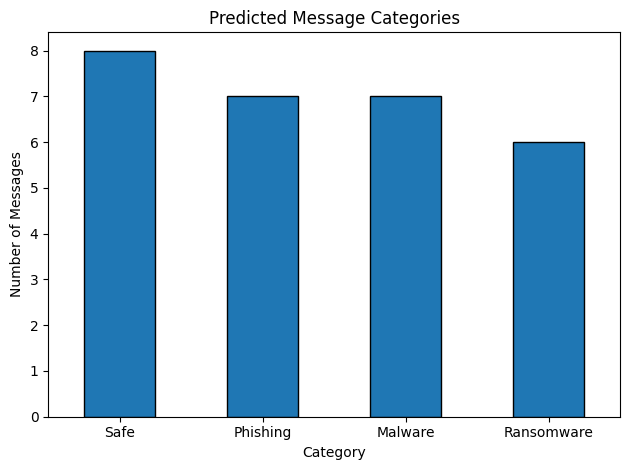

In [9]:
category_order = [
    'Safe',
    'Phishing',
    'Malware',
    'Ransomware'
]

category_counts = (
    df['predicted_category']
    .value_counts()
    .reindex(category_order, fill_value=0)
)

print("Category Counts:")
print(category_counts)

# Create bar chart
category_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Predicted Message Categories')
plt.xlabel('Category')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# **Q5. Responsible Use and Reflection**

In [10]:
responsible_use = [
    "Privacy: Remove personal identifiers before analysis.",
    "Bias: Keyword lists may not cover every writing style or variation.",
    "False alarms: Safe messages may contain warning words.",
    "Accountability: Humans remain responsible for the final decision.",
    "Human review: High-risk or unclear cases should be checked by a human."
]

for point in responsible_use:
    print("-", point)

- Privacy: Remove personal identifiers before analysis.
- Bias: Keyword lists may not cover every writing style or variation.
- False alarms: Safe messages may contain warning words.
- Accountability: Humans remain responsible for the final decision.
- Human review: High-risk or unclear cases should be checked by a human.


# **- Live/New Message Demonstration**

In [11]:
new_message = "Urgent: click here to verify your password"

result = classify_message(new_message)

print("New Message:")
print(new_message)

print("\nClassification Result:")
print(result)

New Message:
Urgent: click here to verify your password

Classification Result:
('Phishing', 'urgent, password, click here, verify', 4)


# **- Save Final Results**


In [12]:
df.to_csv(
    'Lab1_Final_Result.csv',
    index=False
)

print("Saved: Lab1_Final_Result.csv")

Saved: Lab1_Final_Result.csv


In [13]:
df.to_csv(
    'Lab1_Final_Result.csv',
    index=False
)

print("Lab1_Final_Result.csv has been updated.")

# Display the head of the updated CSV to confirm
updated_df = pd.read_csv('Lab1_Final_Result.csv')
print("\nDisplaying the head of the updated Lab1_Final_Result.csv:")
display(updated_df.head())

Lab1_Final_Result.csv has been updated.

Displaying the head of the updated Lab1_Final_Result.csv:


,message_id,message,correct_category,predicted_category,matched_keywords,keyword_score,correct,risk_level,recommended_action
0,1,The department meeting is scheduled for 2 PM i...,Safe,Safe,NaN,0,True,Low,Continue normal caution.
1,2,Your account will be suspended. Click here and...,Phishing,Phishing,"urgent, password, click here, verify",4,True,High,Do not click/open; isolate if required and rep...
2,3,The attached executable file contains a trojan...,Malware,Malware,"executable, trojan",2,True,High,Do not click/open; isolate if required and rep...
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware,Ransomware,"encrypted, bitcoin, restore files",3,True,High,Do not click/open; isolate if required and rep...
4,5,Library books must be returned before Friday.,Safe,Safe,NaN,0,True,Low,Continue normal caution.


# **- Conclusion**

This laboratory exercise showcased the effectiveness of a straightforward rule-based artificial intelligence system in detecting common cyber threats, specifically Phishing, Malware, and Ransomware. The classifier functions by analyzing messages for predefined keywords and counting their occurrences. An impressive accuracy of 96.43% was achieved on the dataset of 28 messages, with 27 correctly identified. The single misclassification occurred because the message's phrasing varied from the exact keywords defined in the rules. This highlights that while keyword-driven systems are transparent and easy to comprehend, they can be vulnerable to variations in language or novel attack methods. Consequently, such systems are best utilized as a supportive tool for human analysts, rather than as fully autonomous decision-makers. Emphasizing privacy protection and incorporating human oversight remains crucial when dealing with potentially sensitive cybersecurity communications.

# **- Key Findings**

1.  **Phishing Indicators**: Messages identified as phishing frequently contained terms like 'urgent', 'verify', 'password', 'OTP', 'bank', 'login', and 'click here'.
2.  **Malware Indicators**: Communications flagged as malware typically included keywords such as 'executable', 'trojan', 'spyware', 'attachment', and 'infected'.
3.  **Ransomware Indicators**: Ransomware messages commonly featured phrases like 'encrypted', 'ransom', 'bitcoin', 'restore files', and 'locked files'.
4.  **Safe Messages**: Generally, messages classified as 'Safe' lacked the specific threat-related keywords defined in our rules.
5.  **Classification Accuracy**: The rule-based classifier achieved a high accuracy of 96.43% on the provided dataset.
6.  **Misclassification Insight**: The single incorrect prediction underscored a limitation of exact keyword matching, as it failed to capture nuances in alternative phrasing.
7.  **Risk Assignment**: Risk levels were assigned dynamically based on the predicted threat category and the density of matched keywords.
8.  **Human Element**: It was concluded that human oversight is indispensable, particularly for messages categorized as high-risk or those with ambiguous classifications.